In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style="darkgrid")
sns.set_palette("husl")

In [3]:
df = pd.read_csv("Pakistan_corporate_Employee_Analysis.csv")

In [4]:
df.head()

,Name,Age,Gender,City,Department,Salary,Experience,Rating,Projects_Completed,Satisfaction_Score,Education,Overtime_Hours,Bonus,Leaves_Taken,Performance
0,Person_1,56,Male,Karachi,Sales,50963,28,1.1,19,8.3,Intermediate,20,48924,22,Excellent
1,Person_2,46,Male,Islamabad,Engineering,126757,21,1.3,38,3.3,Masters,24,16709,14,Excellent
2,Person_3,32,Male,Quetta,HR,195515,4,4.6,3,3.2,Matric,19,9726,0,Good
3,Person_4,60,Male,Karachi,Engineering,124259,29,1.6,5,4.6,Bachelors,21,40542,20,Average
4,Person_5,25,Male,Lahore,Sales,64063,22,3.1,13,9.1,PhD,20,20245,24,Good


In [5]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
City                  0
Department            0
Salary                0
Experience            0
Rating                0
Projects_Completed    0
Satisfaction_Score    0
Education             0
Overtime_Hours        0
Bonus                 0
Leaves_Taken          0
Performance           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

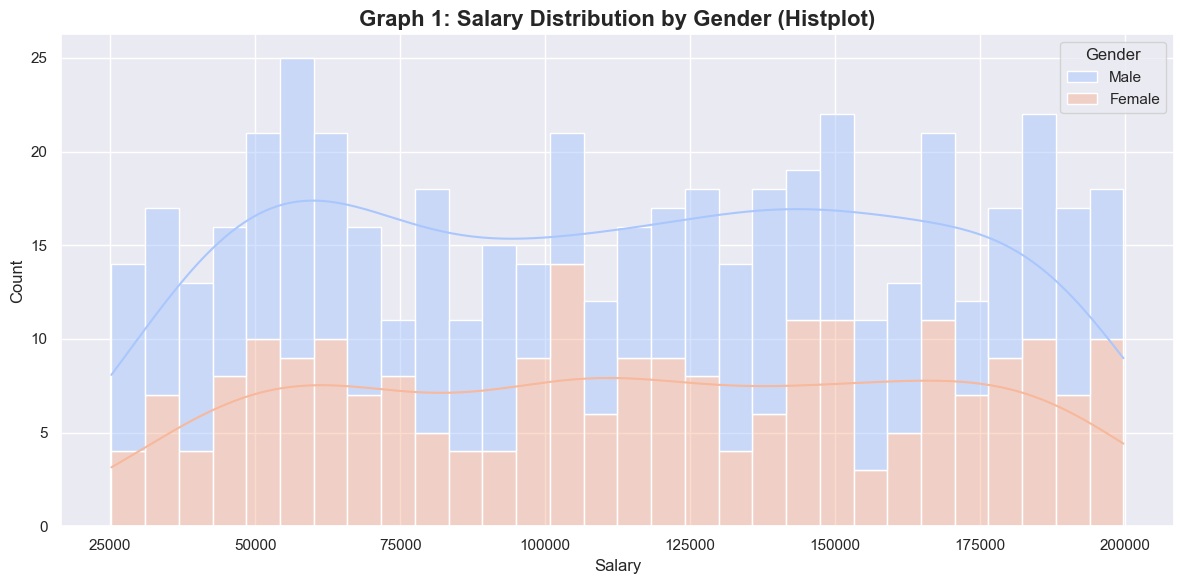

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Salary', bins=30, kde=True, hue='Gender', multiple='stack', palette='coolwarm')
plt.title('Graph 1: Salary Distribution by Gender (Histplot)', fontsize=16, fontweight='bold')
plt.xlabel('Salary', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('01_histplot.png', dpi=150)
plt.show()

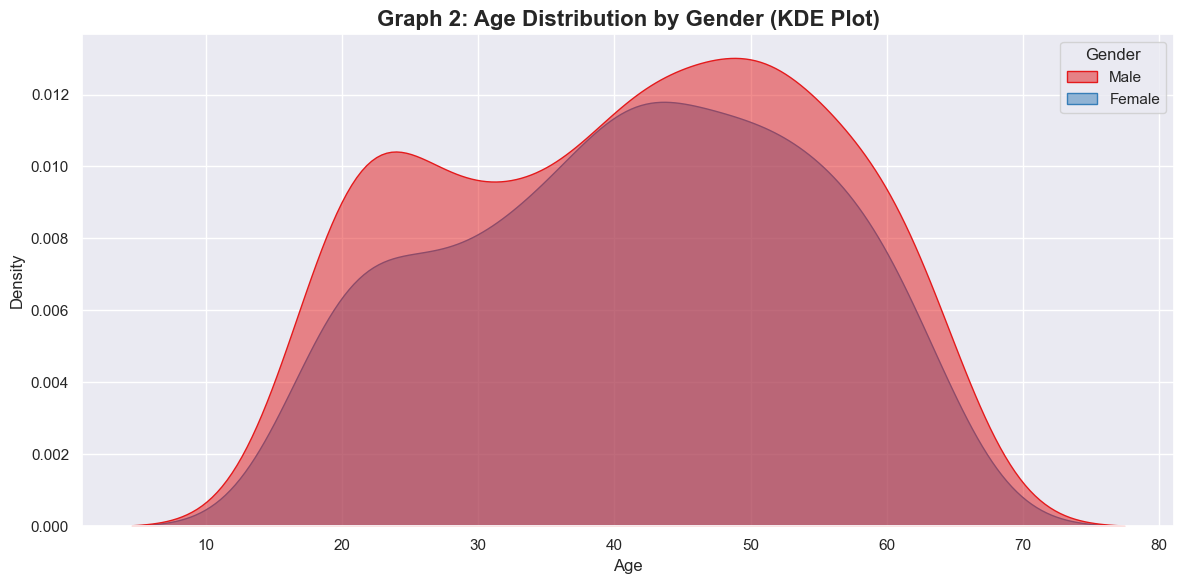

In [8]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Age', hue='Gender', fill=True, palette='Set1', alpha=0.5)
plt.title('Graph 2: Age Distribution by Gender (KDE Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.savefig('02_kdeplot.png', dpi=150)
plt.show()

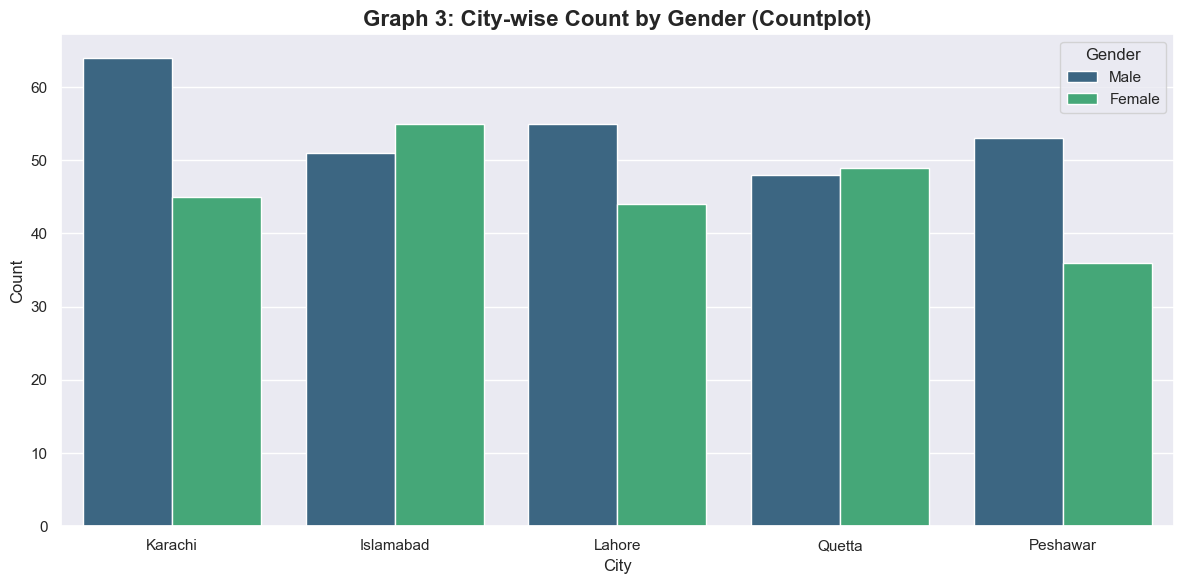

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='City', hue='Gender', palette='viridis', order=df['City'].value_counts().index)
plt.title('Graph 3: City-wise Count by Gender (Countplot)', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('03_countplot.png', dpi=150)
plt.show()

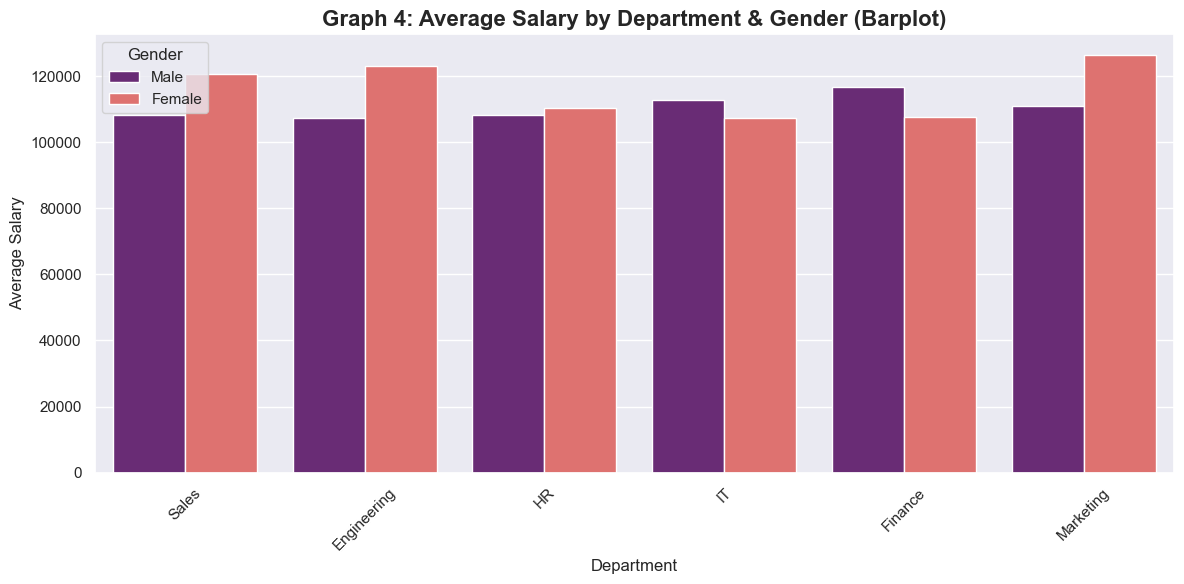

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Department', y='Salary', hue='Gender', palette='magma', ci=None, estimator=np.mean)
plt.title('Graph 4: Average Salary by Department & Gender (Barplot)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Salary', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('04_barplot.png', dpi=150)
plt.show()

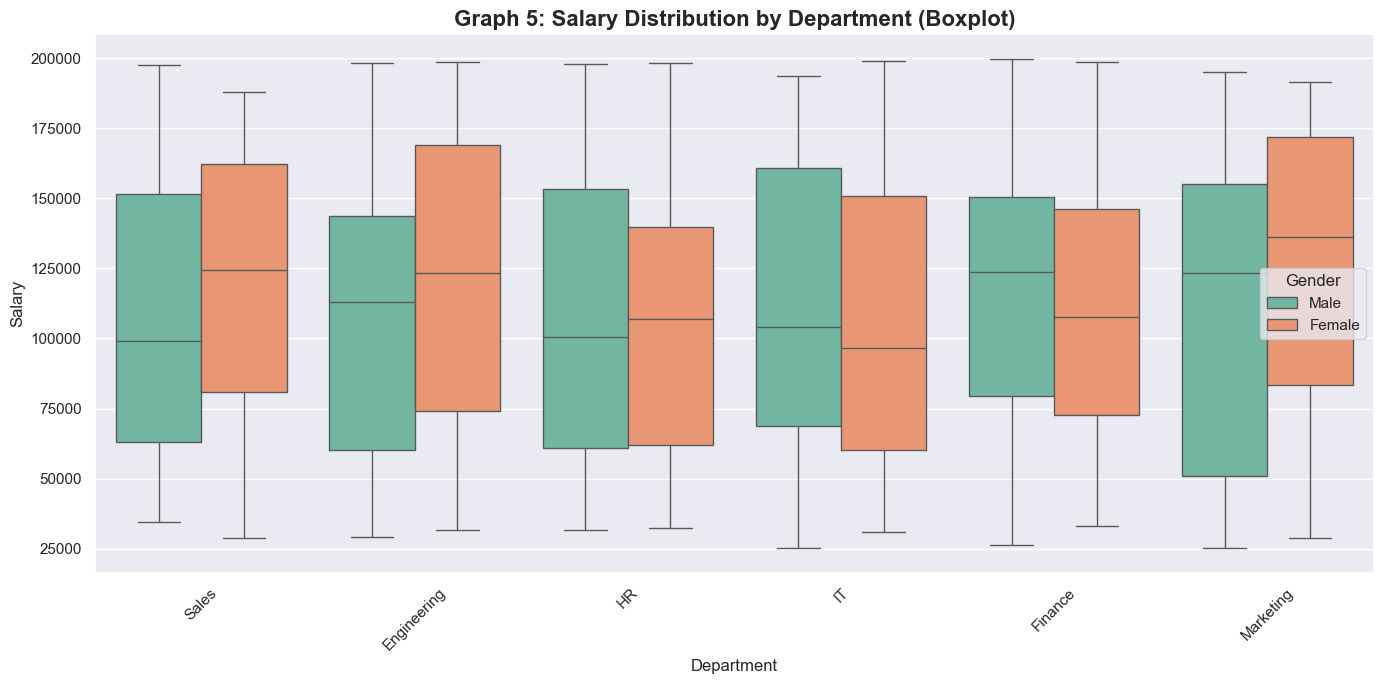

In [11]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Department', y='Salary', hue='Gender', palette='Set2')
plt.title('Graph 5: Salary Distribution by Department (Boxplot)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('05_boxplot.png', dpi=150)
plt.show()

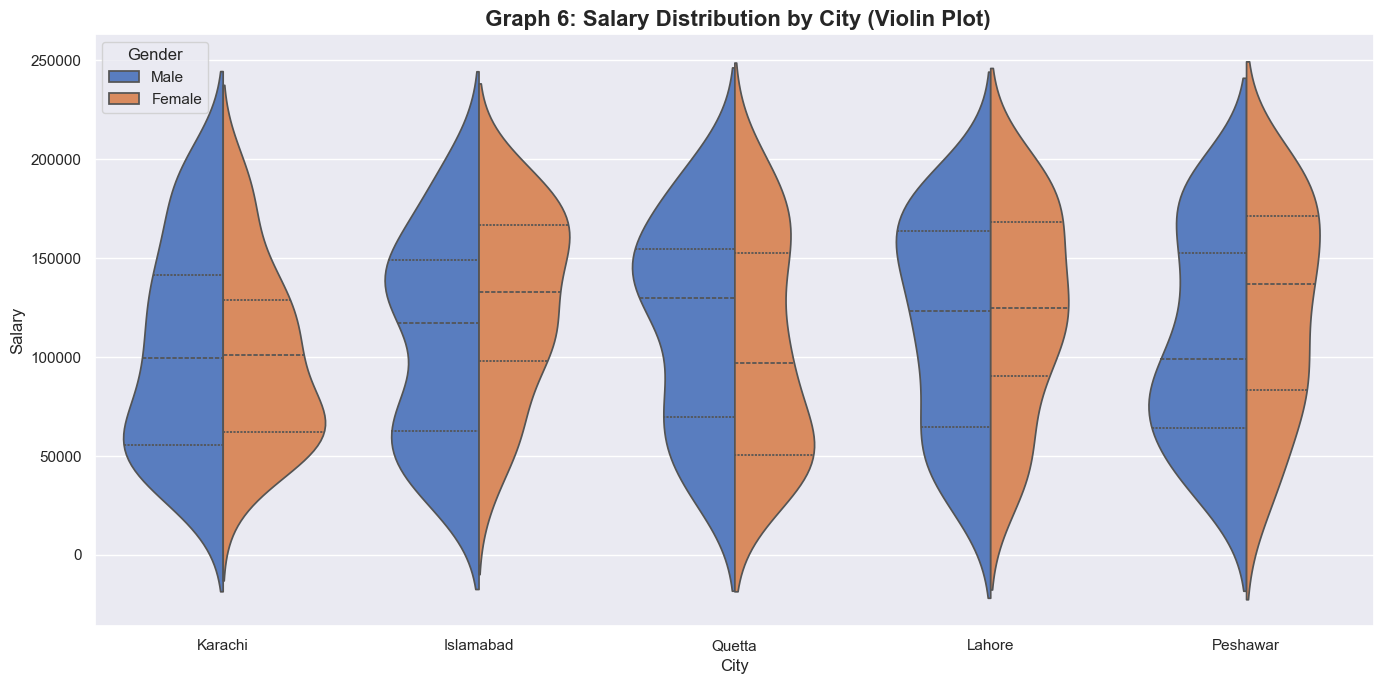

In [12]:
plt.figure(figsize=(14, 7))
sns.violinplot(data=df, x='City', y='Salary', hue='Gender', split=True, palette='muted', inner='quart')
plt.title(' Graph 6: Salary Distribution by City (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.tight_layout()
plt.savefig('06_violinplot.png', dpi=150)
plt.show()

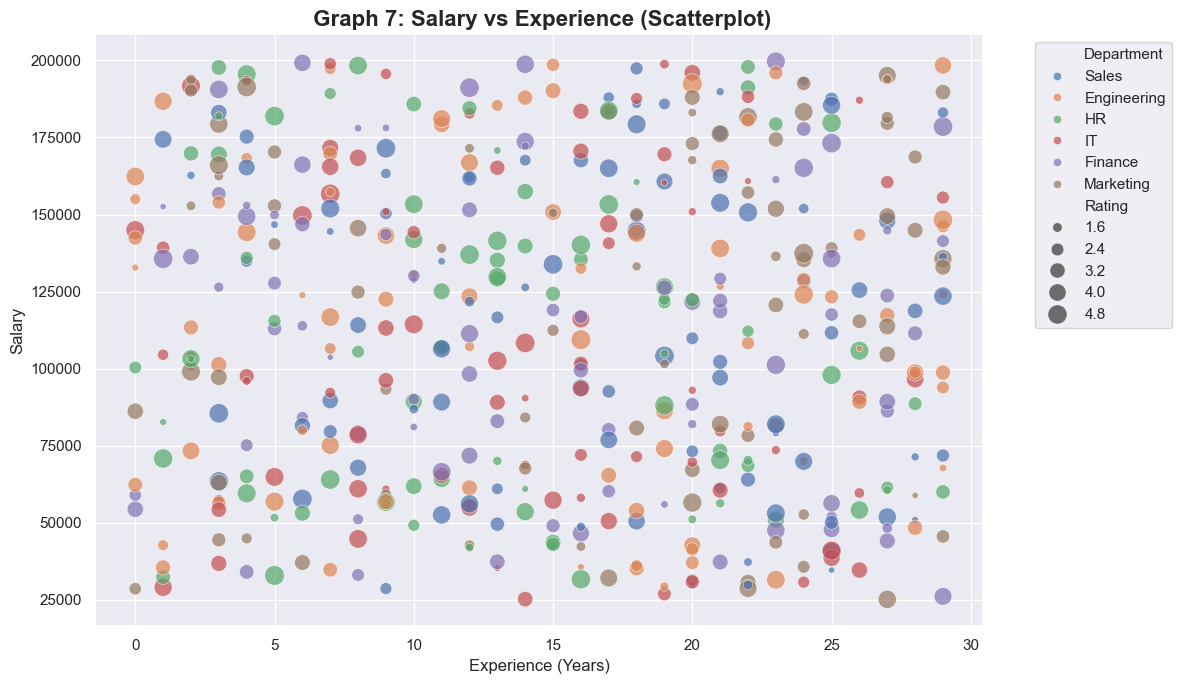

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Experience', y='Salary', hue='Department', size='Rating',
                sizes=(20, 200), palette='deep', alpha=0.7)
plt.title(' Graph 7: Salary vs Experience (Scatterplot)', fontsize=16, fontweight='bold')
plt.xlabel('Experience (Years)', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('07_scatterplot.png', dpi=150)
plt.show()

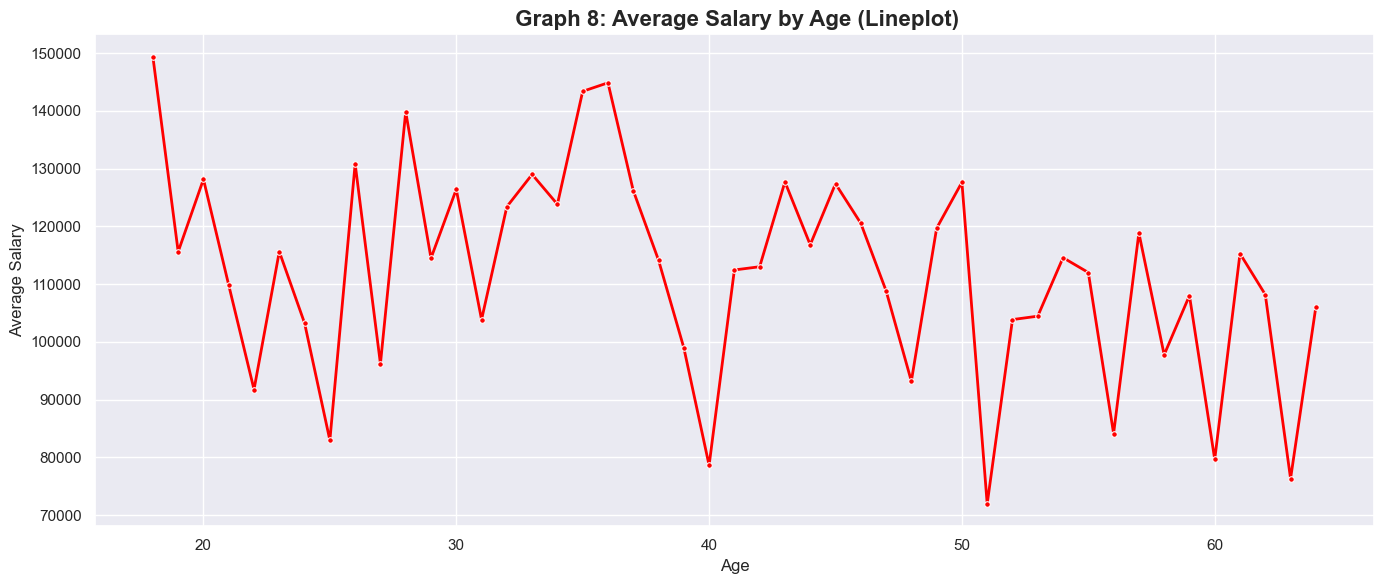

In [14]:
plt.figure(figsize=(14, 6))
age_salary = df.groupby('Age')['Salary'].mean().reset_index()
sns.lineplot(data=age_salary, x='Age', y='Salary', color='red', linewidth=2, marker='o', markersize=4)
plt.title(' Graph 8: Average Salary by Age (Lineplot)', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Salary', fontsize=12)
plt.tight_layout()
plt.savefig('08_lineplot.png', dpi=150)
plt.show()

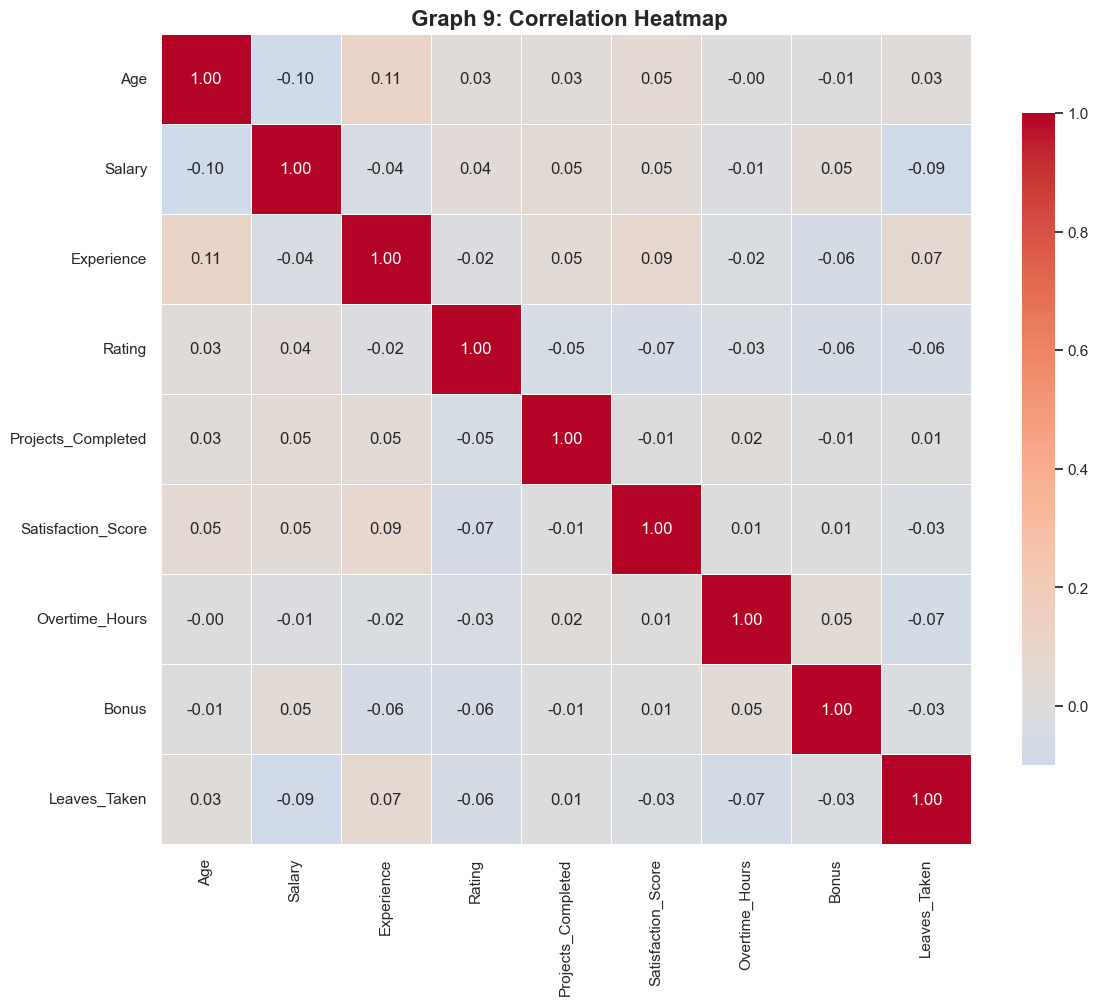

In [15]:
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title(' Graph 9: Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('09_heatmap.png', dpi=150)
plt.show()

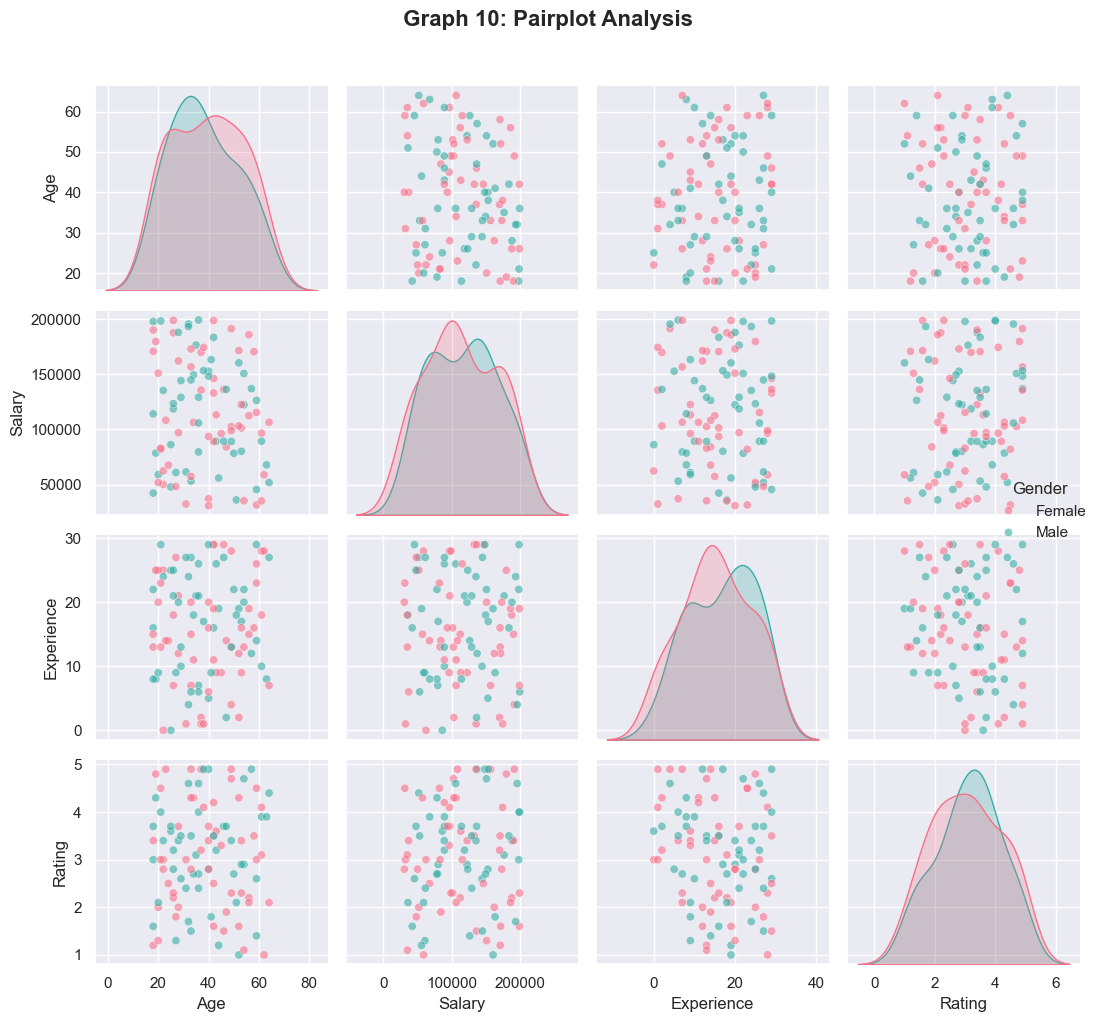

In [16]:
pair_data = df[['Age', 'Salary', 'Experience', 'Rating', 'Gender']].sample(100)
g = sns.pairplot(pair_data, hue='Gender', palette='husl', diag_kind='kde',
                 plot_kws={'alpha': 0.6}, height=2.5)
g.fig.suptitle(' Graph 10: Pairplot Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('10_pairplot.png', dpi=150)
plt.show()

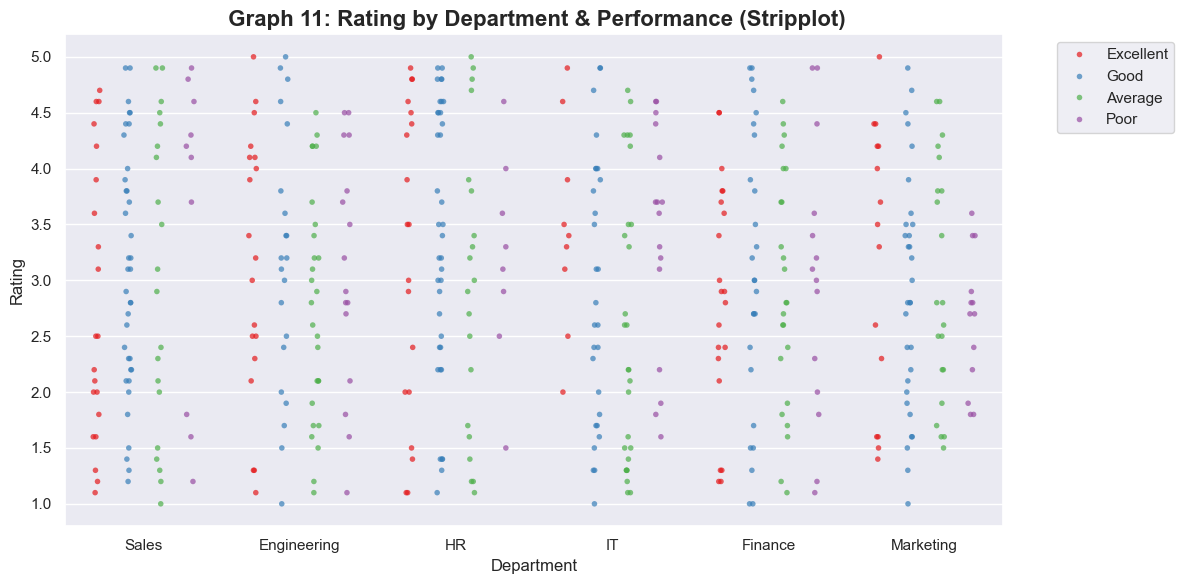

In [17]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df, x='Department', y='Rating', hue='Performance',
              palette='Set1', dodge=True, jitter=True, alpha=0.7, size=4)
plt.title(' Graph 11: Rating by Department & Performance (Stripplot)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('11_stripplot.png', dpi=150)
plt.show()

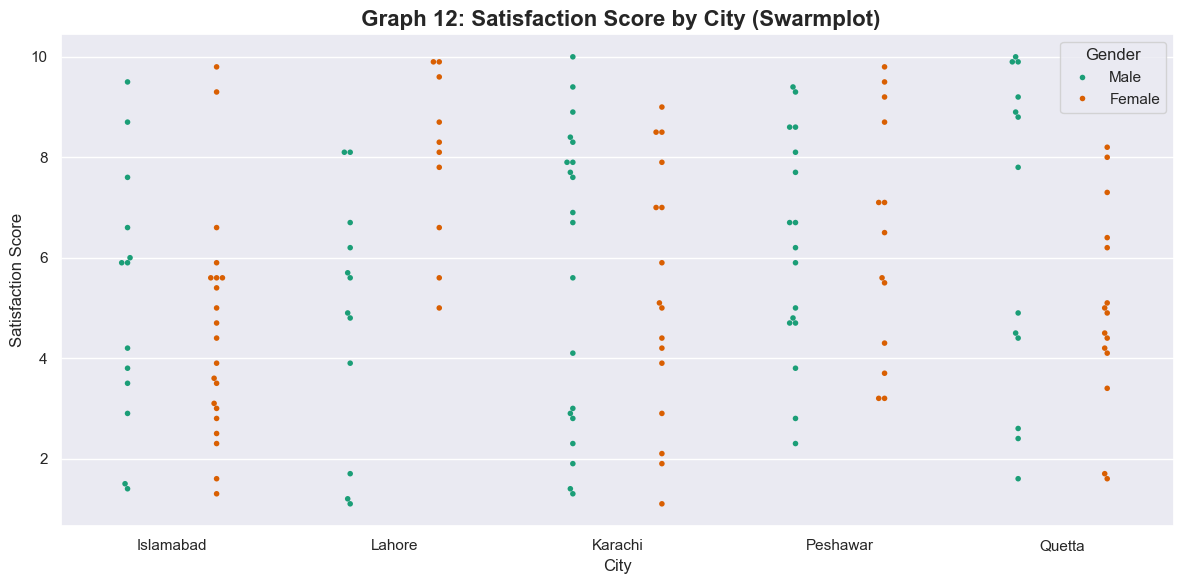

In [18]:
plt.figure(figsize=(12, 6))
sample_data = df.sample(150)
sns.swarmplot(data=sample_data, x='City', y='Satisfaction_Score', hue='Gender', palette='Dark2', dodge=True, size=4)
plt.title(' Graph 12: Satisfaction Score by City (Swarmplot)', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Satisfaction Score', fontsize=12)
plt.tight_layout()
plt.savefig('12_swarmplot.png', dpi=150)
plt.show()

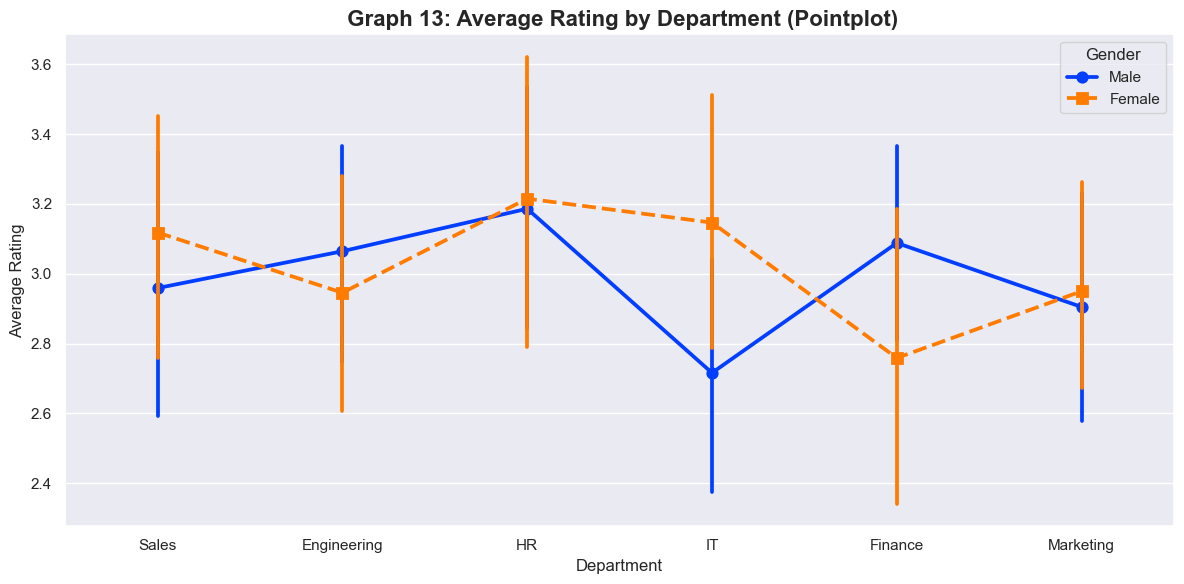

In [19]:
plt.figure(figsize=(12, 6))
sns.pointplot(data=df, x='Department', y='Rating', hue='Gender',
              palette='bright', markers=['o', 's'], linestyles=['-', '--'], ci=95)
plt.title(' Graph 13: Average Rating by Department (Pointplot)', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.tight_layout()
plt.savefig('13_pointplot.png', dpi=150)
plt.show()

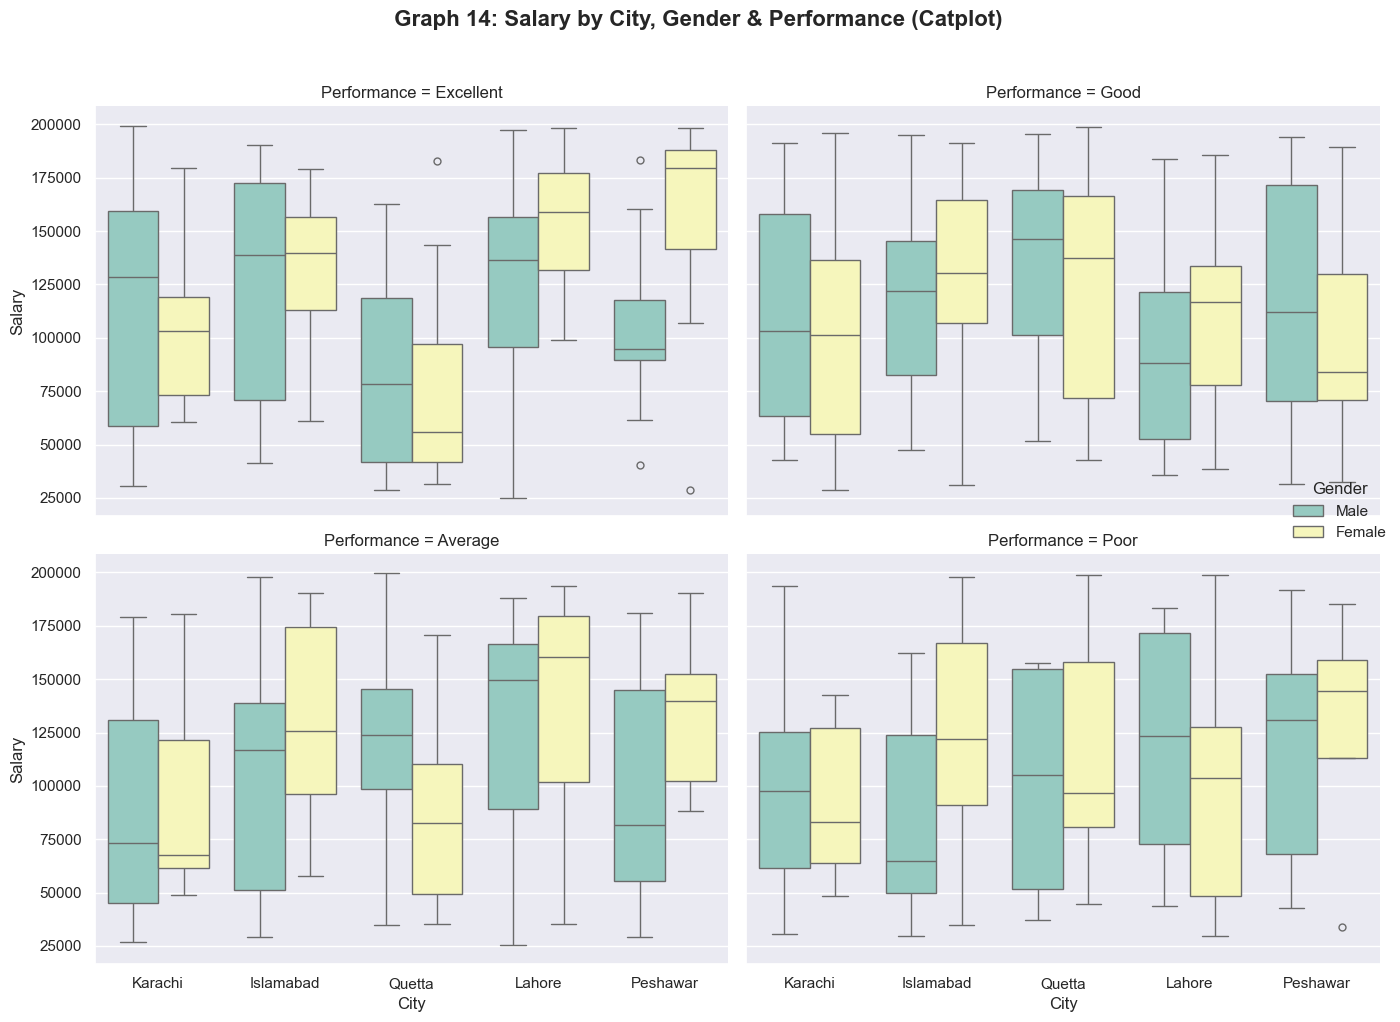

In [20]:
g = sns.catplot(data=df, x='City', y='Salary', hue='Gender', col='Performance',
                kind='box', col_wrap=2, height=5, aspect=1.3, palette='Set3')
g.fig.suptitle(' Graph 14: Salary by City, Gender & Performance (Catplot)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('14_catplot.png', dpi=150)
plt.show()

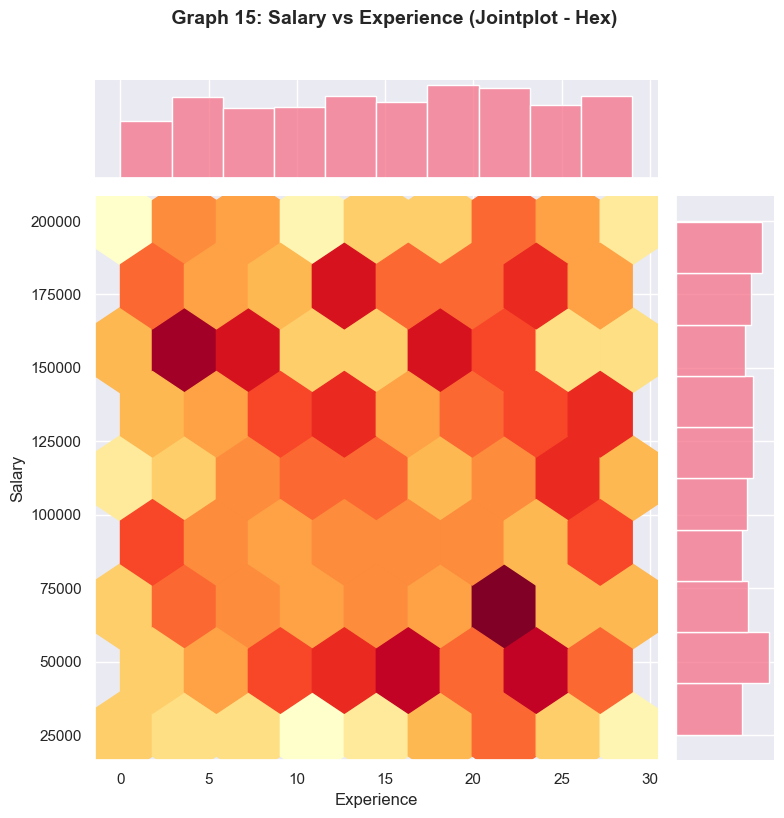

In [21]:
g = sns.jointplot(data=df, x='Experience', y='Salary', kind='hex', cmap='YlOrRd', height=8)
g.fig.suptitle(' Graph 15: Salary vs Experience (Jointplot - Hex)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('15_jointplot_hex.png', dpi=150)
plt.show()

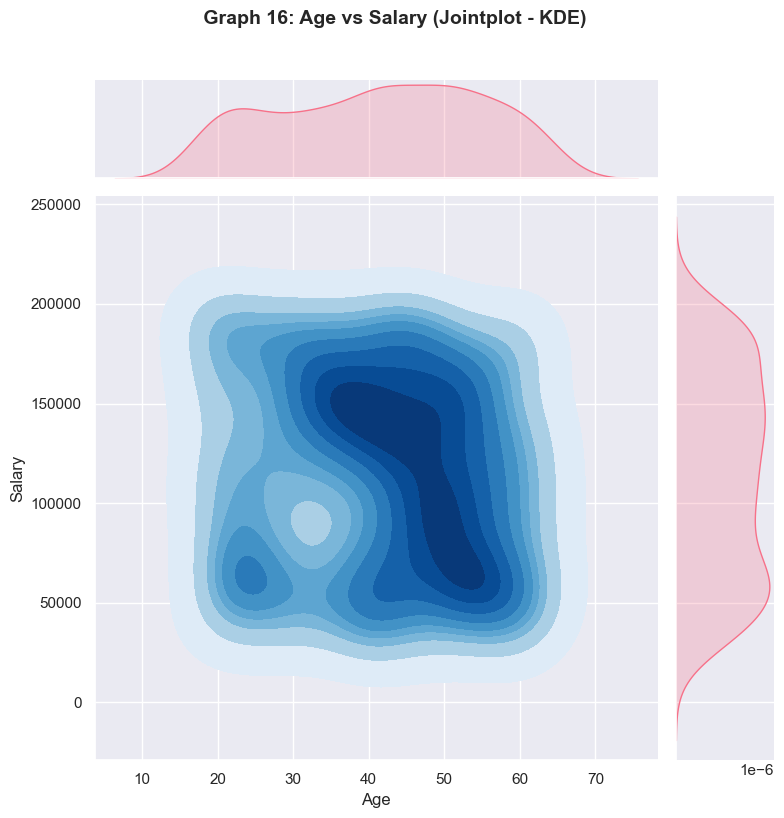

In [22]:
g = sns.jointplot(data=df, x='Age', y='Salary', kind='kde', cmap='Blues', fill=True, height=8)
g.fig.suptitle(' Graph 16: Age vs Salary (Jointplot - KDE)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('16_jointplot_kde.png', dpi=150)
plt.show()

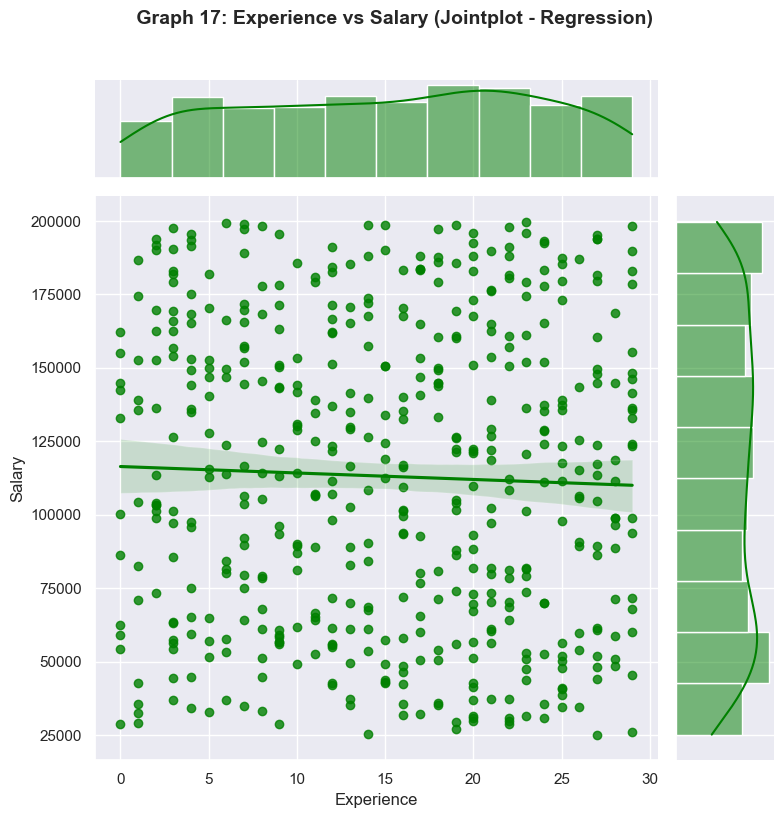

In [23]:
g = sns.jointplot(data=df, x='Experience', y='Salary', kind='reg', color='green', height=8)
g.fig.suptitle(' Graph 17: Experience vs Salary (Jointplot - Regression)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('17_jointplot_reg.png', dpi=150)
plt.show()

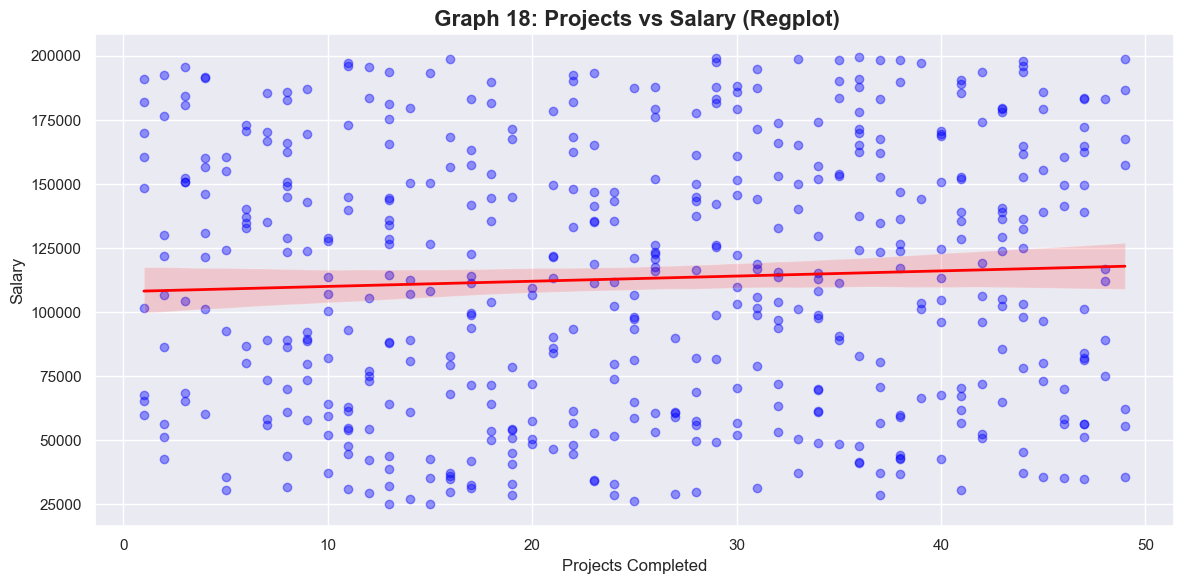

In [24]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='Projects_Completed', y='Salary', scatter_kws={'alpha': 0.4, 'color': 'blue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title(' Graph 18: Projects vs Salary (Regplot)', fontsize=16, fontweight='bold')
plt.xlabel('Projects Completed', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.tight_layout()
plt.savefig('18_regplot.png', dpi=150)
plt.show()

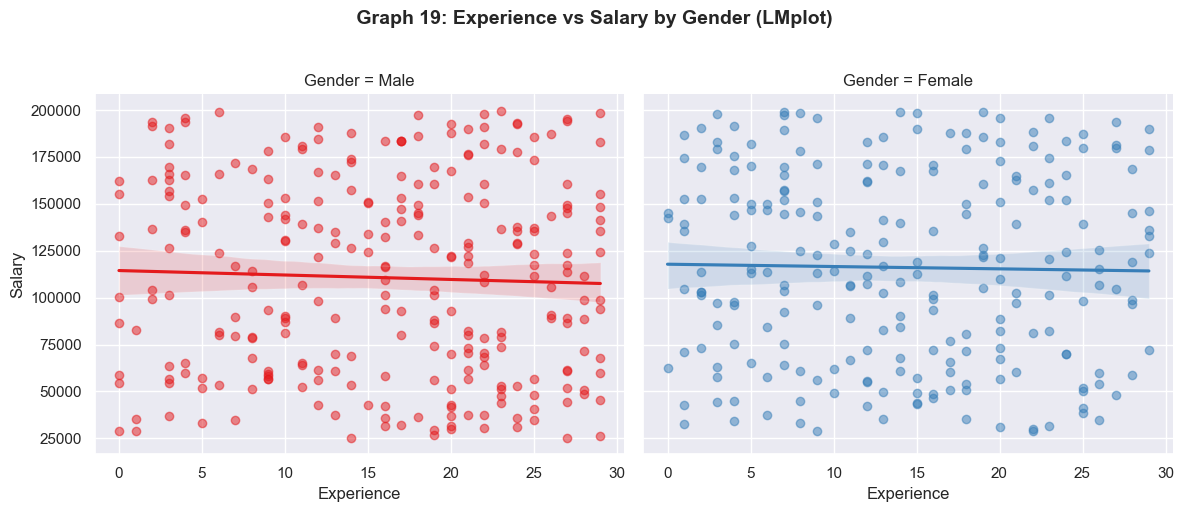

In [25]:
g = sns.lmplot(data=df, x='Experience', y='Salary', hue='Gender', col='Gender',
               palette='Set1', height=5, aspect=1.2, scatter_kws={'alpha': 0.5})
g.fig.suptitle(' Graph 19: Experience vs Salary by Gender (LMplot)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('19_lmplot.png', dpi=150)
plt.show()

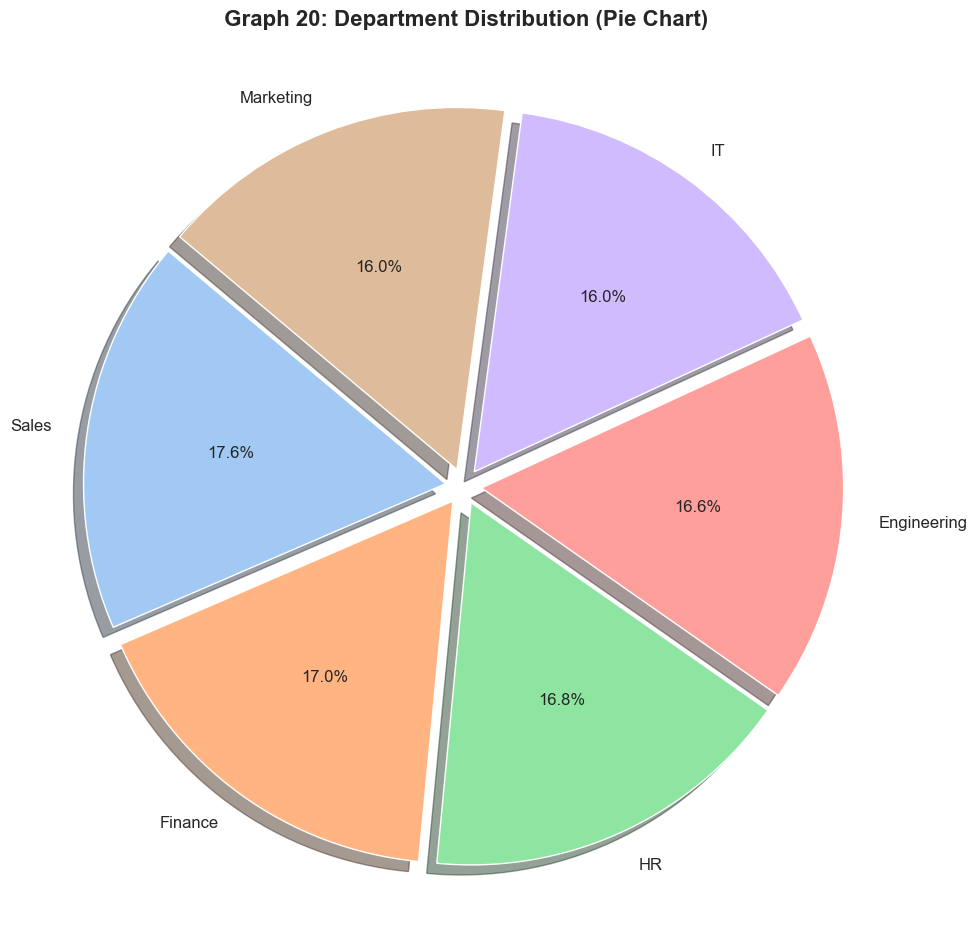

In [26]:
plt.figure(figsize=(10, 10))
dept_counts = df['Department'].value_counts()
colors = sns.color_palette('pastel', len(dept_counts))
plt.pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, textprops={'fontsize': 12},
        explode=[0.05]*len(dept_counts), shadow=True)
plt.title(' Graph 20: Department Distribution (Pie Chart)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('20_piechart.png', dpi=150)
plt.show()